
# Wolfe parameter sensitivity study

This notebook keeps only the four Wolfe line-search methods:
- GradientDescentW
- NewtonW
- BFGSW
- DFPW

It runs them on all 12 problems, varies `c1_ls` and `c2_ls`, saves detailed results, and draws a few representative plots for an initial study.


In [1]:

import csv
import math
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
HEATMAP_DIR = ROOT / "heatmap"
HEATMAP_DIR.mkdir(parents=True, exist_ok=True)
CODESPACE = ROOT / "codespace"
if str(CODESPACE) not in sys.path:
    sys.path.insert(0, str(CODESPACE))
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if "/mnt/data" not in sys.path:
    sys.path.insert(0, "/mnt/data")

import functions
import optSolver as _optSolver_module


def optSolver(problem, method, options):
    """Template-compatible solver entrypoint."""
    if hasattr(_optSolver_module, "optSolver"):
        return _optSolver_module.optSolver(problem, method, options)
    return _optSolver_module.Solver(problem, method, options)


print(f"Using solver from: {_optSolver_module.__file__}")


Using solver from: d:\Filez\Desktop\homework\IOE511\IOE511_Project\codespace\optSolver.py


In [2]:
# initialization
class Problem:
    def __init__(self, name, x0, func, grad, hess):
        self.name = name
        self.x0 = np.asarray(x0, dtype=float)
        self._func = func
        self._grad = grad
        self._hess = hess
        self.f_eval = 0
        self.g_eval = 0
        self.h_eval = 0

    def compute_f(self, x):
        self.f_eval += 1
        return float(self._func(np.asarray(x, dtype=float)))

    def compute_g(self, x):
        self.g_eval += 1
        return np.asarray(self._grad(np.asarray(x, dtype=float)), dtype=float)

    def compute_H(self, x):
        self.h_eval += 1
        return np.asarray(self._hess(np.asarray(x, dtype=float)), dtype=float)


class Method:
    def __init__(self, name, **options):
        self.name = name
        self.options = options


class Options:
    def __init__(self, term_tol=1e-6, max_iterations=1000, **kwargs):
        self.term_tol = term_tol
        self.max_iterations = max_iterations
        for key, value in kwargs.items():
            setattr(self, key, value)


def make_spd(n, kappa, rng):
    A = rng.standard_normal((n, n))
    Q_orth, _ = np.linalg.qr(A)
    eigvals = np.geomspace(1.0, float(kappa), num=n)
    return Q_orth @ np.diag(eigvals) @ Q_orth.T


def build_problem_specs(seed=0): # insert all the problems that we need to investigate
    rng = np.random.default_rng(seed)
    specs = []

    # P1-P4: quadratics
    for name, n, kappa in [
        ("P1_quad_10_10", 10, 10),
        ("P2_quad_10_1000", 10, 1000),
        ("P3_quad_1000_10", 1000, 10),
        ("P4_quad_1000_1000", 1000, 1000),
    ]:
        Q = make_spd(n, kappa, rng)
        q = rng.uniform(-10.0, 10.0, size=n)
        x0 = rng.uniform(-10.0, 10.0, size=n)
        specs.append({
            "name": name,
            "x0": x0,
            "func": lambda x, Q=Q, q=q: functions.Quad_func(x, Q, q),
            "grad": lambda x, Q=Q, q=q: functions.Quad_grad(x, Q, q),
            "hess": lambda x, Q=Q, q=q: functions.Quad_Hess(x, Q, q),
        })

    # P5-P6: quartic
    Q4 = np.array([
        [5.0, 1.0, 0.0, 0.5],
        [1.0, 4.0, 0.5, 0.0],
        [0.0, 0.5, 3.0, 0.0],
        [0.5, 0.0, 0.0, 2.0],
    ])
    x0_q = np.array([np.cos(70.0), np.sin(70.0), np.cos(70.0), np.sin(70.0)])
    specs.append({
        "name": "P5_quartic_1e-4",
        "x0": x0_q,
        "func": lambda x: functions.Quartic_func(x, Q4, 1e-4),
        "grad": lambda x: functions.Quartic_grad(x, Q4, 1e-4),
        "hess": lambda x: functions.Quartic_hess(x, Q4, 1e-4),
    })
    specs.append({
        "name": "P6_quartic_1e4",
        "x0": x0_q,
        "func": lambda x: functions.Quartic_func(x, Q4, 1e4),
        "grad": lambda x: functions.Quartic_grad(x, Q4, 1e4),
        "hess": lambda x: functions.Quartic_hess(x, Q4, 1e4),
    })

    # P7-P8: Rosenbrock
    specs.append({
        "name": "P7_rosenbrock_2",
        "x0": np.array([-1.2, 1.0]),
        "func": functions.Rosenbrock_func,
        "grad": functions.Rosenbrock_grad,
        "hess": functions.Rosenbrock_hess,
    })
    x0_r100 = np.ones(100)
    x0_r100[0] = -1.2
    specs.append({
        "name": "P8_rosenbrock_100",
        "x0": x0_r100,
        "func": functions.Rosenbrock_func,
        "grad": functions.Rosenbrock_grad,
        "hess": functions.Rosenbrock_hess,
    })

    # P9: data fitting
    specs.append({
        "name": "P9_datafit_2",
        "x0": np.array([1.0, 1.0]),
        "func": functions.Datafit_func,
        "grad": functions.Datafit_grad,
        "hess": functions.Datafit_hess,
    })

    # P10-P11: exponential
    x0_e10 = np.zeros(10)
    x0_e10[0] = 1.0
    specs.append({
        "name": "P10_exponential_10",
        "x0": x0_e10,
        "func": functions.Exponential_func,
        "grad": functions.Exponential_grad,
        "hess": functions.Exponential_hess,
    })
    x0_e100 = np.zeros(100)
    x0_e100[0] = 1.0
    specs.append({
        "name": "P11_exponential_100",
        "x0": x0_e100,
        "func": functions.Exponential_func,
        "grad": functions.Exponential_grad,
        "hess": functions.Exponential_hess,
    })

    # P12: genhumps
    specs.append({
        "name": "P12_genhumps_5",
        "x0": np.array([-506.2, 506.2, -506.2, 506.2, -506.2]),
        "func": functions.Genhumps_func,
        "grad": functions.Genhumps_grad,
        "hess": functions.Genhumps_hess,
    })

    return specs


PROBLEM_SPECS = build_problem_specs(seed=0)
METHODS = ["GradientDescentW", "NewtonW", "BFGSW", "DFPW"]

GLOBAL_OPTIONS = {
    "term_tol": 1e-6,
    "max_iterations": 1000,
    "c1_ls": 1e-4,
    "c2_ls": 0.9,
}

METHOD_DEFAULTS = { # this big question only looks into the 4 algorithms using armijo & wolfe line search
    "GradientDescentW": {"alpha0": 1.0, "c1_ls": 1e-4, "c2_ls": 0.9},
    "NewtonW": {"alpha0": 1.0, "c1_ls": 1e-4, "c2_ls": 0.9},
    "BFGSW": {"alpha0": 1.0, "c1_ls": 1e-4, "c2_ls": 0.9},
    "DFPW": {"alpha0": 1.0, "c1_ls": 1e-4, "c2_ls": 0.9},
}

print(f"Prepared {len(PROBLEM_SPECS)} problems and {len(METHODS)} Wolfe methods.")


Prepared 12 problems and 4 Wolfe methods.


In [3]:

def run_one_experiment(problem_spec, method_name, c1_ls, c2_ls, method_options=None, global_options=None):
    method_options = dict(method_options or METHOD_DEFAULTS[method_name])
    method_options["c1_ls"] = c1_ls
    method_options["c2_ls"] = c2_ls

    merged_global = dict(GLOBAL_OPTIONS if global_options is None else global_options)
    merged_global["c1_ls"] = c1_ls
    merged_global["c2_ls"] = c2_ls

    problem = Problem(
        name=problem_spec["name"],
        x0=problem_spec["x0"],
        func=problem_spec["func"],
        grad=problem_spec["grad"],
        hess=problem_spec["hess"],
    )
    method = Method(method_name, **method_options)
    options = Options(**merged_global)

    t0 = time.perf_counter()
    status = "ok"
    error_msg = ""
    x_final = None
    f_final = np.nan
    f_hist = []
    alpha_hist = []

    try:
        out = optSolver(problem, method, options)
        if len(out) == 4:
            x_final, f_final, f_hist, alpha_hist = out
        else:
            x_final, f_final, f_hist = out
    except Exception as exc:
        status = "fail"
        error_msg = str(exc)

    cpu_sec = time.perf_counter() - t0
    iterations = max(len(f_hist) - 1, 0)
    grad_inf = np.nan
    if status == "ok" and x_final is not None:
        try:
            grad_inf = np.linalg.norm(problem.compute_g(x_final), ord=np.inf)
        except Exception:
            grad_inf = np.nan

    return {
        "problem": problem_spec["name"],
        "method": method_name,
        "c1_ls": float(c1_ls),
        "c2_ls": float(c2_ls),
        "status": status,
        "iterations": int(iterations),
        "f_eval": int(problem.f_eval),
        "g_eval": int(problem.g_eval),
        "h_eval": int(problem.h_eval),
        "cpu_sec": float(cpu_sec),
        "f_final": float(f_final) if np.isfinite(f_final) else np.nan,
        "grad_inf": float(grad_inf) if np.isfinite(grad_inf) else np.nan,
        "error": error_msg,
        "f_hist": list(f_hist),
        "alpha_hist": list(alpha_hist),
    }


# Wolfe grid
c1_grid = [1e-5, 0.00005, 1e-4, 0.0005, 1e-3, 0.005, 1e-2, 0.05, 0.099] # c1 should be close to 0
c2_grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99] # c2 must be larger than c1
param_grid = [(c1, c2) for c1 in c1_grid for c2 in c2_grid if c1 < c2]

print(f"Valid Wolfe parameter pairs: {len(param_grid)}")
print(param_grid)


Valid Wolfe parameter pairs: 90
[(1e-05, 0.1), (1e-05, 0.2), (1e-05, 0.3), (1e-05, 0.4), (1e-05, 0.5), (1e-05, 0.6), (1e-05, 0.7), (1e-05, 0.8), (1e-05, 0.9), (1e-05, 0.99), (5e-05, 0.1), (5e-05, 0.2), (5e-05, 0.3), (5e-05, 0.4), (5e-05, 0.5), (5e-05, 0.6), (5e-05, 0.7), (5e-05, 0.8), (5e-05, 0.9), (5e-05, 0.99), (0.0001, 0.1), (0.0001, 0.2), (0.0001, 0.3), (0.0001, 0.4), (0.0001, 0.5), (0.0001, 0.6), (0.0001, 0.7), (0.0001, 0.8), (0.0001, 0.9), (0.0001, 0.99), (0.0005, 0.1), (0.0005, 0.2), (0.0005, 0.3), (0.0005, 0.4), (0.0005, 0.5), (0.0005, 0.6), (0.0005, 0.7), (0.0005, 0.8), (0.0005, 0.9), (0.0005, 0.99), (0.001, 0.1), (0.001, 0.2), (0.001, 0.3), (0.001, 0.4), (0.001, 0.5), (0.001, 0.6), (0.001, 0.7), (0.001, 0.8), (0.001, 0.9), (0.001, 0.99), (0.005, 0.1), (0.005, 0.2), (0.005, 0.3), (0.005, 0.4), (0.005, 0.5), (0.005, 0.6), (0.005, 0.7), (0.005, 0.8), (0.005, 0.9), (0.005, 0.99), (0.01, 0.1), (0.01, 0.2), (0.01, 0.3), (0.01, 0.4), (0.01, 0.5), (0.01, 0.6), (0.01, 0.7), (0.01, 0.8

In [4]:
# full parameter study on all 12 problems
all_rows = []
for p in PROBLEM_SPECS:
    print(f"Running {p['name']} ...")
    for method_name in METHODS:
        for c1_ls, c2_ls in param_grid:
            row = run_one_experiment(
                problem_spec=p,
                method_name=method_name,
                c1_ls=c1_ls,
                c2_ls=c2_ls,
            )
            all_rows.append(row)

print(f"Finished {len(all_rows)} total runs.")
print(f"Successful runs: {sum(r['status'] == 'ok' for r in all_rows)} / {len(all_rows)}")

summary_csv = ROOT / "wolfe_parameter_sensitivity_detailed.csv"
fieldnames = [
    "problem", "method", "c1_ls", "c2_ls", "status", "iterations",
    "f_eval", "g_eval", "h_eval", "cpu_sec", "f_final", "grad_inf", "error"
]
with summary_csv.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for r in all_rows:
        writer.writerow({k: r[k] for k in fieldnames})

print(f"Saved detailed summary to: {summary_csv}")


Running P1_quad_10_10 ...
Running P2_quad_10_1000 ...
Running P3_quad_1000_10 ...
Running P4_quad_1000_1000 ...
Running P5_quartic_1e-4 ...
Running P6_quartic_1e4 ...
Running P7_rosenbrock_2 ...
Running P8_rosenbrock_100 ...
Running P9_datafit_2 ...
Running P10_exponential_10 ...


d:\Filez\Desktop\homework\IOE511\IOE511_Project\codespace\functions.py:100: RuntimeWarning: overflow encountered in exp
  term2 = 0.1 * np.exp(-x[0])
d:\Filez\Desktop\homework\IOE511\IOE511_Project\codespace\functions.py:109: RuntimeWarning: overflow encountered in exp
  g[0] = (2 * expx / (denom**2)) - 0.1 * np.exp(-x[0])


Running P11_exponential_100 ...
Running P12_genhumps_5 ...
Finished 4320 total runs.
Successful runs: 4320 / 4320
Saved detailed summary to: d:\Filez\Desktop\homework\IOE511\IOE511_Project\codespace\wolfe_parameter_sensitivity_detailed.csv


In [5]:
# change the color of the images
import seaborn as sns
cmap = sns.color_palette(
    "blend:#00274C,#1F4E79,#FFCB05",
    as_cmap=True
)

,problem,method,c1_ls,c2_ls,status,iterations,f_eval,g_eval,h_eval,cpu_sec,f_final,grad_inf,error
0,P1_quad_10_10,GradientDescentW,0.00001,0.1,ok,44,149,150,0,0.001130,-71.42913,0.000032,
1,P1_quad_10_10,GradientDescentW,0.00001,0.2,ok,44,149,150,0,0.000969,-71.42913,0.000032,
2,P1_quad_10_10,GradientDescentW,0.00001,0.3,ok,44,149,150,0,0.000949,-71.42913,0.000032,
3,P1_quad_10_10,GradientDescentW,0.00001,0.4,ok,44,149,150,0,0.000992,-71.42913,0.000032,
4,P1_quad_10_10,GradientDescentW,0.00001,0.5,ok,44,149,150,0,0.000954,-71.42913,0.000032,


Saved aggregate summary to: d:\Filez\Desktop\homework\IOE511\IOE511_Project\codespace\wolfe_parameter_sensitivity_aggregate.csv

Aggregate table preview:


,method,c1_ls,c2_ls,success_rate,avg_iterations,avg_f_eval,avg_g_eval,avg_cpu_sec
88,BFGSW,0.099,0.90,1.0,43.750000,287.666667,288.666667,1.227752
89,BFGSW,0.099,0.99,1.0,43.750000,287.666667,288.666667,0.848758
84,BFGSW,0.099,0.50,1.0,41.750000,287.750000,288.750000,1.905985
83,BFGSW,0.099,0.40,1.0,40.916667,288.083333,289.083333,1.231398
86,BFGSW,0.099,0.70,1.0,44.500000,289.750000,290.750000,2.056299
87,BFGSW,0.099,0.80,1.0,44.666667,289.750000,290.750000,2.042968
82,BFGSW,0.099,0.30,1.0,40.666667,290.000000,291.000000,1.167538
85,BFGSW,0.099,0.60,1.0,44.500000,290.750000,291.750000,2.056492
81,BFGSW,0.099,0.20,1.0,41.166667,292.500000,293.500000,1.116439
80,BFGSW,0.099,0.10,1.0,40.666667,293.583333,294.583333,1.140320


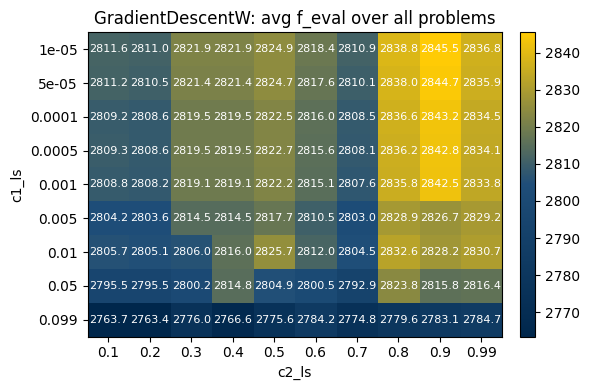

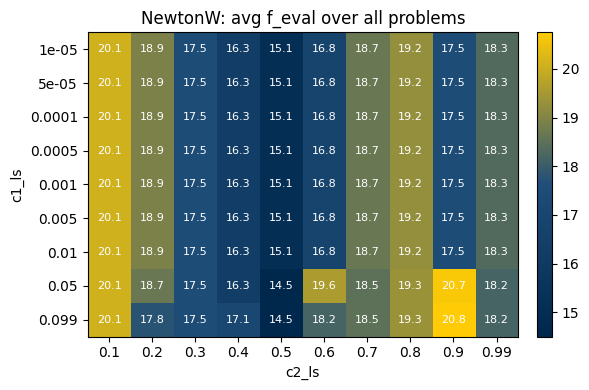

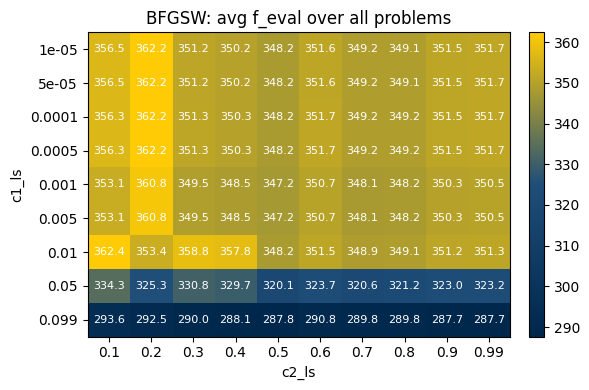

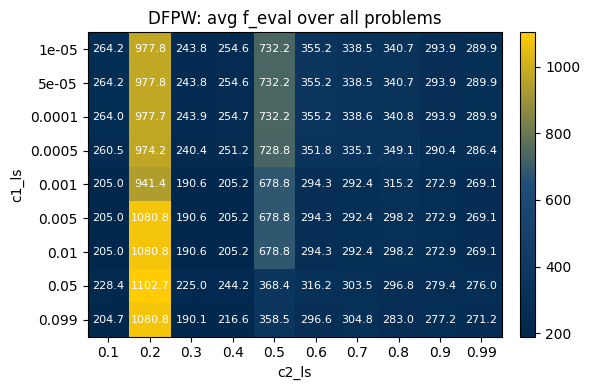

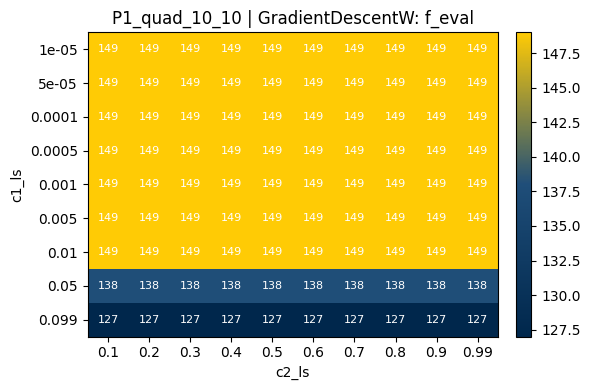

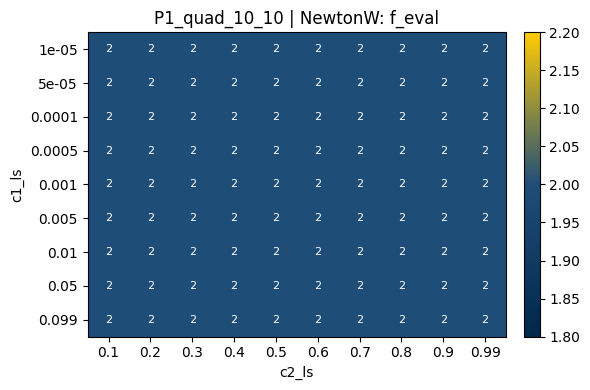

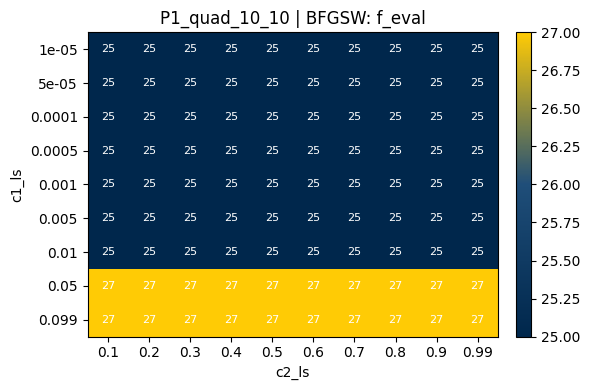

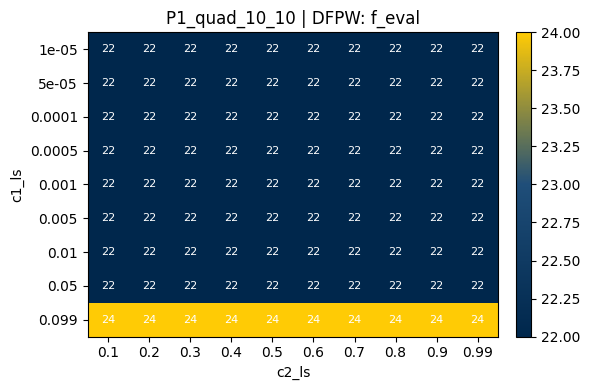

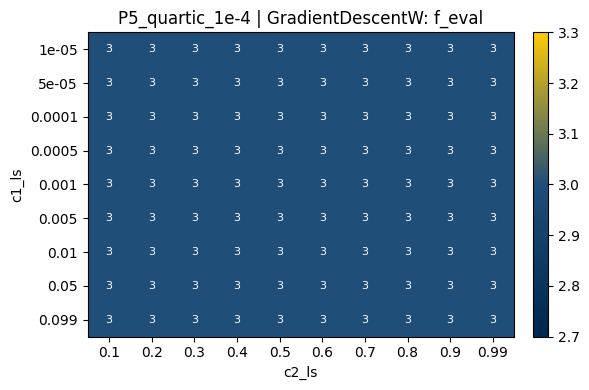

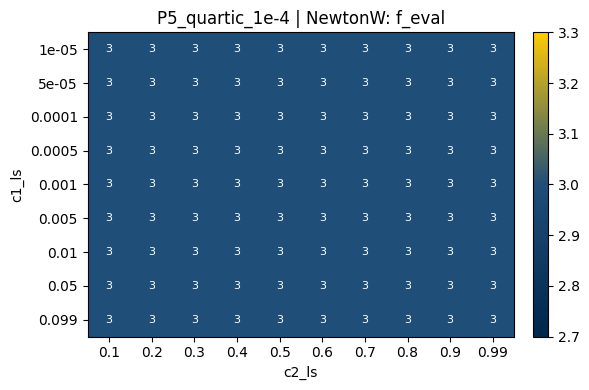

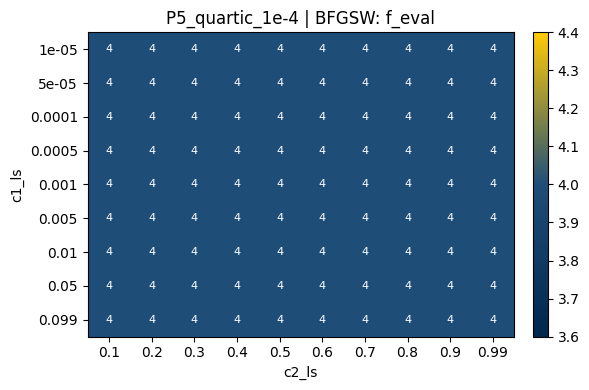

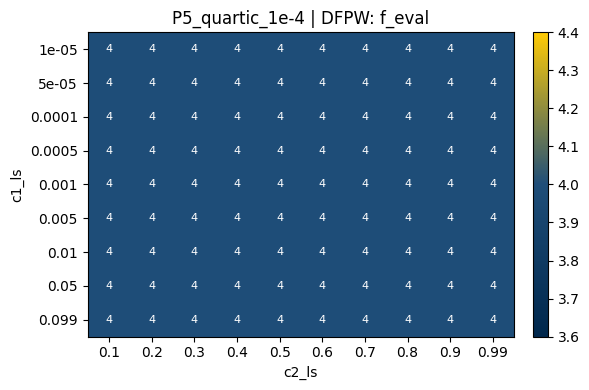

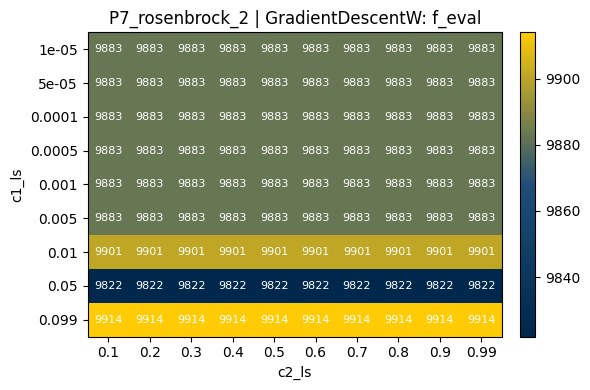

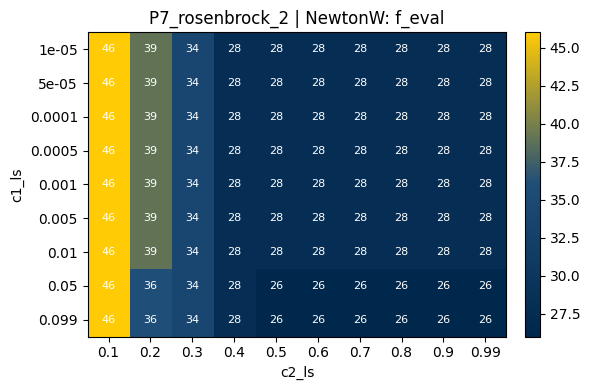

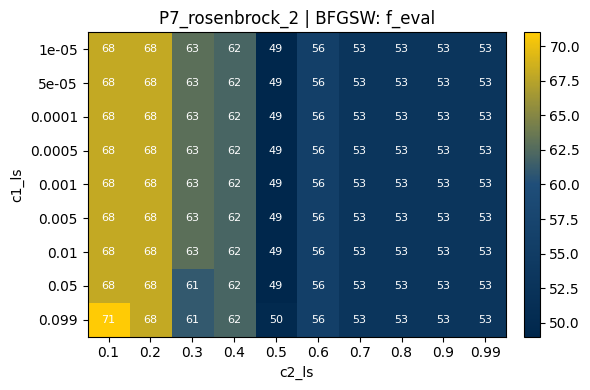

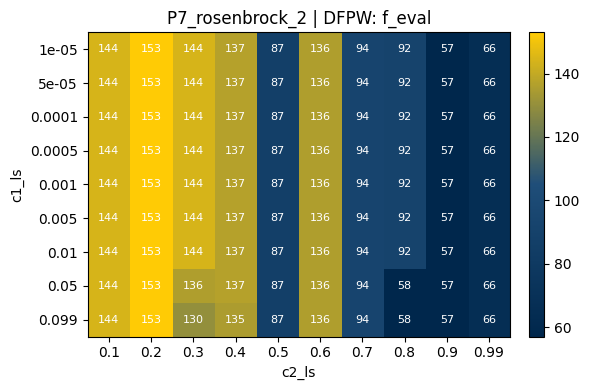

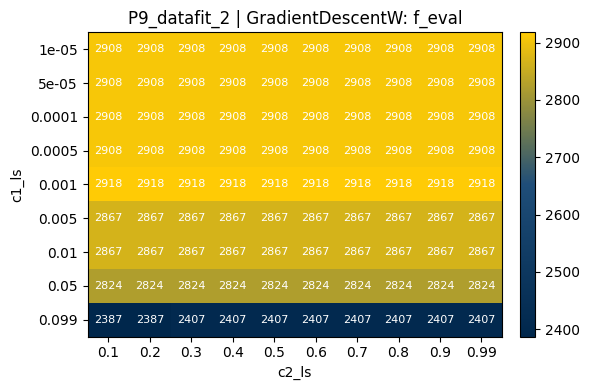

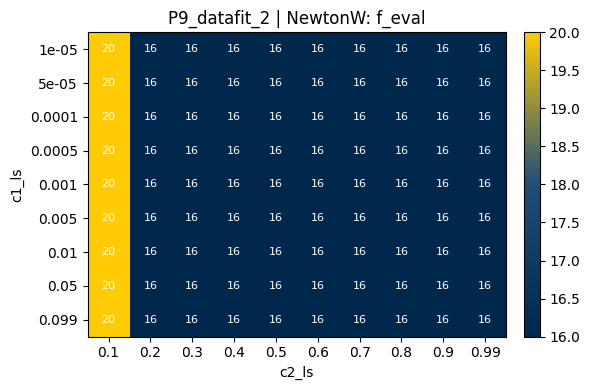

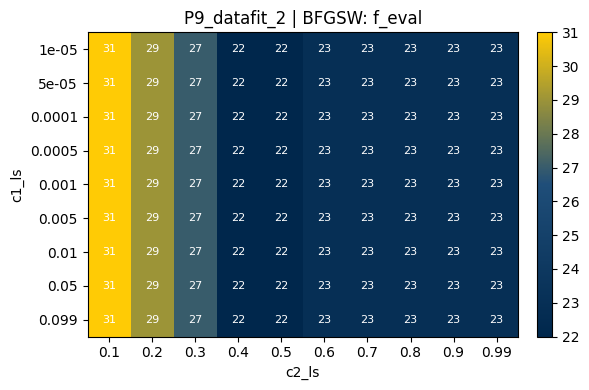

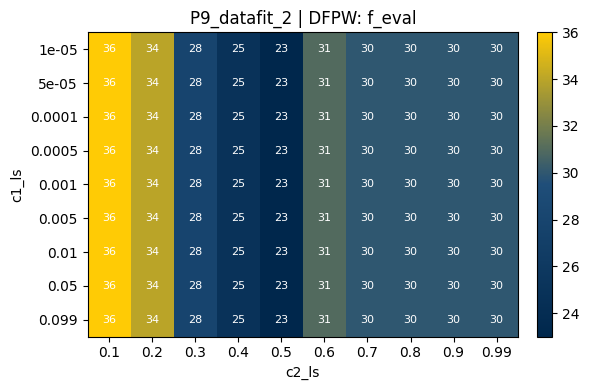

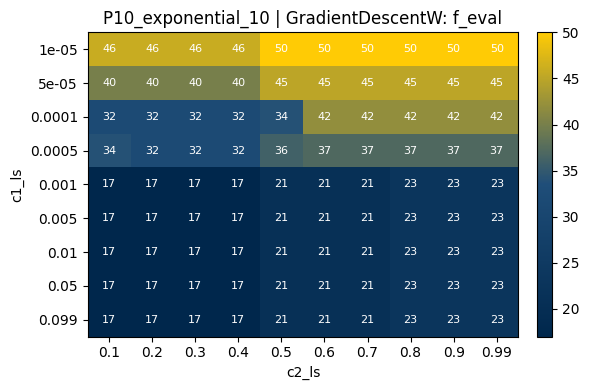

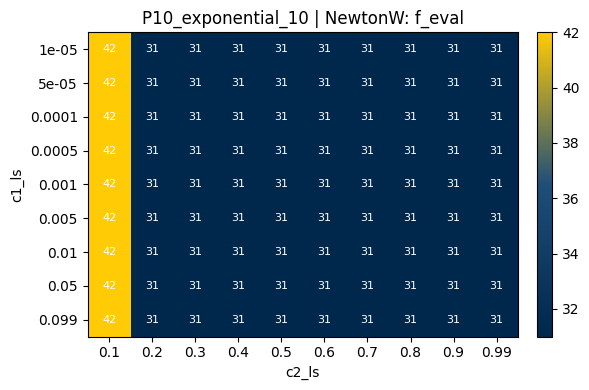

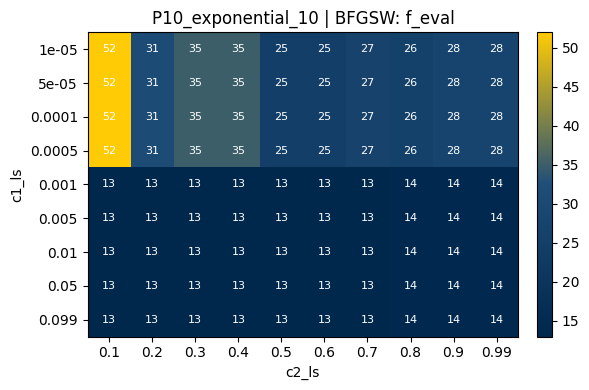

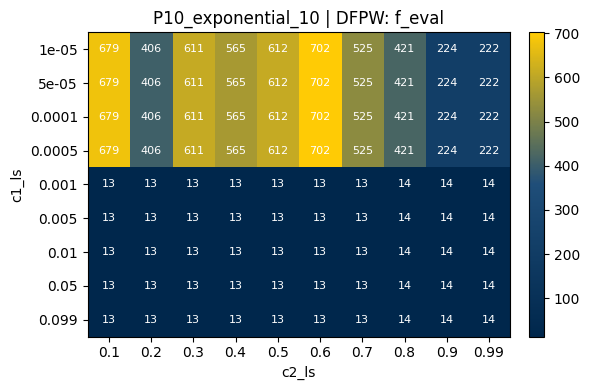

Best average parameter pair for each method (by avg_f_eval, then avg_iterations, then avg_cpu_sec):


,method,c1_ls,c2_ls,success_rate,avg_iterations,avg_f_eval,avg_cpu_sec
0,BFGSW,0.099,0.99,1.0,43.750000,287.666667,0.848758
1,DFPW,0.099,0.30,1.0,41.250000,190.083333,0.297815
2,GradientDescentW,0.099,0.20,1.0,300.166667,2763.416667,0.796685
3,NewtonW,0.050,0.50,1.0,7.666667,14.500000,0.009825


In [6]:


try:
    import pandas as pd
except ImportError:
    pd = None

if pd is None:
    print("pandas is not installed. Use the saved CSV externally.")
else:
    df = pd.DataFrame([{k: v for k, v in r.items() if k not in {"f_hist", "alpha_hist"}} for r in all_rows])
    display(df.head())

    df["success"] = (df["status"] == "ok").astype(int)

    # Aggregate over all 12 problems: average performance of each parameter pair for each algorithm
    agg = (
        df.groupby(["method", "c1_ls", "c2_ls"], as_index=False)
          .agg(
              success_rate=("success", "mean"),
              avg_iterations=("iterations", "mean"),
              avg_f_eval=("f_eval", "mean"),
              avg_g_eval=("g_eval", "mean"),
              avg_cpu_sec=("cpu_sec", "mean"),
          )
    )

    agg_csv = ROOT / "wolfe_parameter_sensitivity_aggregate.csv"
    agg.to_csv(agg_csv, index=False)
    print(f"Saved aggregate summary to: {agg_csv}")

    print("\nAggregate table preview:")
    display(agg.sort_values(["method", "avg_f_eval"]).head(12))

    representative_problems = ["P1_quad_10_10", "P5_quartic_1e-4", "P7_rosenbrock_2", "P9_datafit_2", "P10_exponential_10"]

    def draw_heatmap(ax, data, title, value_col, fmt=".1f", cmap="viridis"):
        heat = np.full((len(c1_grid), len(c2_grid)), np.nan)
        for i, c1 in enumerate(c1_grid):
            for j, c2 in enumerate(c2_grid):
                if c1 >= c2:
                    continue
                match = data[(data["c1_ls"] == c1) & (data["c2_ls"] == c2)]
                if len(match):
                    heat[i, j] = match.iloc[0][value_col]
        im = ax.imshow(heat, cmap=cmap, aspect="auto")
        ax.set_xticks(range(len(c2_grid)))
        ax.set_xticklabels([str(v) for v in c2_grid])
        ax.set_yticks(range(len(c1_grid)))
        ax.set_yticklabels([str(v) for v in c1_grid])
        ax.set_xlabel("c2_ls")
        ax.set_ylabel("c1_ls")
        ax.set_title(title)
        for i in range(len(c1_grid)):
            for j in range(len(c2_grid)):
                val = heat[i, j]
                if np.isnan(val):
                    ax.text(j, i, "--", ha="center", va="center", color="white", fontsize=8)
                else:
                    ax.text(j, i, format(val, fmt), ha="center", va="center", color="white", fontsize=8)
        return im

    # Plot 1: aggregated heatmaps over all problems
    for method_name in METHODS:
        sub = agg[agg["method"] == method_name]
        fig, ax = plt.subplots(figsize=(6, 4))
        im = draw_heatmap(
            ax,
            sub,
            f"{method_name}: avg f_eval over all problems",
            "avg_f_eval",
            fmt=".1f",
            cmap=cmap
        )
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        fig.patch.set_alpha(0)
        plt.savefig(HEATMAP_DIR / f"heatmap_{method_name}.png", dpi=300, transparent=True, bbox_inches="tight")
        plt.show()

    # Plot 2: detailed heatmaps for a few representative problems only
    for p_name in representative_problems:
        for method_name in METHODS:
            sub = df[(df["problem"] == p_name) & (df["method"] == method_name)]
            fig, ax = plt.subplots(figsize=(6, 4))
            im1 = draw_heatmap(ax, sub, f"{p_name} | {method_name}: f_eval", "f_eval", fmt=".0f", cmap=cmap)
            plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
            plt.tight_layout()
            fig.patch.set_alpha(0)
            plt.savefig(HEATMAP_DIR / f"heatmap_{method_name}_{p_name}.png", dpi=300, transparent=True, bbox_inches="tight")
            plt.show()

    # Plot 3: best parameter pair on average for each algorithm
    best_by_method = agg.sort_values(["method", "avg_f_eval", "avg_iterations", "avg_cpu_sec"]).groupby("method", as_index=False).first()
    print("Best average parameter pair for each method (by avg_f_eval, then avg_iterations, then avg_cpu_sec):")
    display(best_by_method[["method", "c1_ls", "c2_ls", "success_rate", "avg_iterations", "avg_f_eval", "avg_cpu_sec"]])


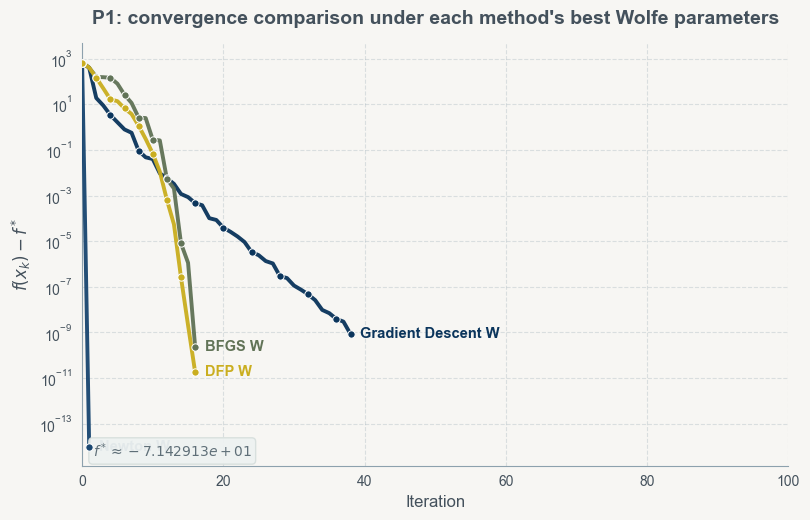

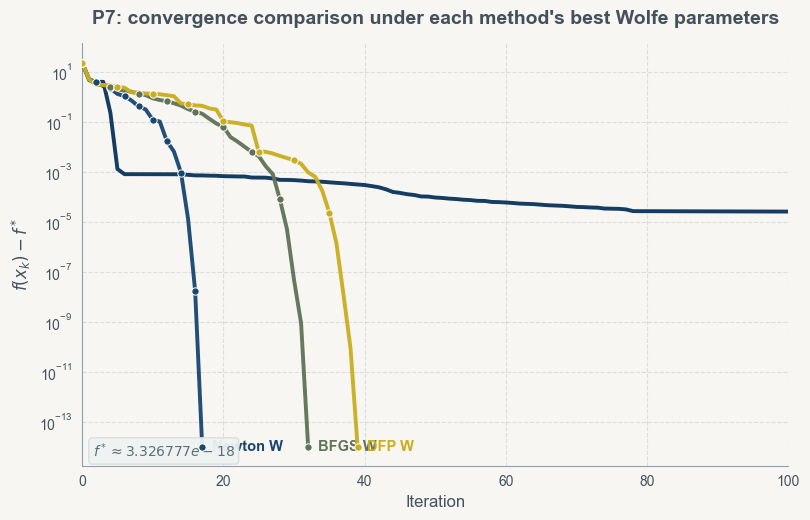

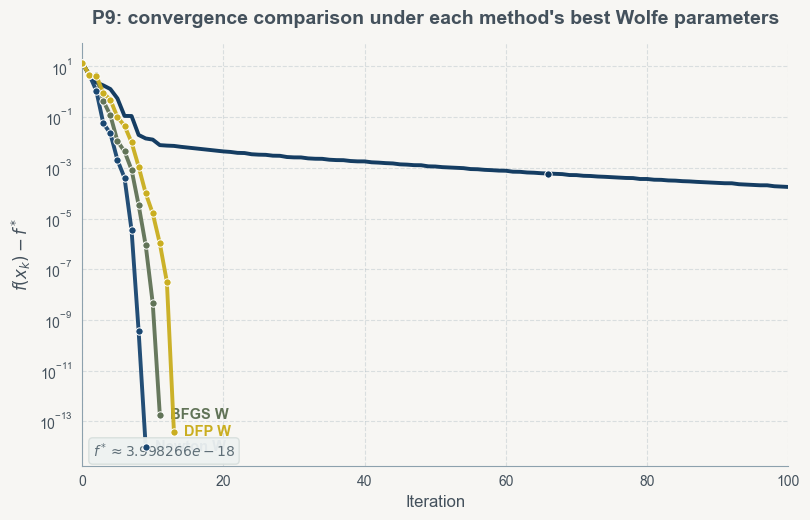

In [7]:

# Plot 4: convergence curves on P1, P7, and P9 only (one figure per problem)
# Uses the actual run results already stored in all_rows. Existing heatmaps above are left unchanged.

try:
    import pandas as pd
except ImportError:
    pd = None

if pd is None:
    print("pandas is not installed. Skip convergence-curve plots.")
else:
    runs_df = pd.DataFrame(all_rows)

    selected_problem_map = {
        "P1": "P1_quad_10_10",
        "P7": "P7_rosenbrock_2",
        "P9": "P9_datafit_2",
    }

    # Reuse the same Morandi-style cmap idea from the heatmaps
    try:
        import seaborn as sns
        if "cmap" not in globals():
            cmap = sns.color_palette(
                "blend:#d8e2dc,#9bbac7,#e8a7b1",
                as_cmap=True
            )
        sns.set_style("white")
    except Exception:
        from matplotlib.colors import LinearSegmentedColormap
        if "cmap" not in globals():
            cmap = LinearSegmentedColormap.from_list(
                "morandi",
                ["#d8e2dc", "#9bbac7", "#e8a7b1"]
            )

    line_colors = [cmap(v) for v in np.linspace(0.18, 0.88, len(METHODS))]

    def _best_successful_row(sub_df):
        ok = sub_df[(sub_df["status"] == "ok") & sub_df["f_hist"].map(lambda x: isinstance(x, list) and len(x) > 0)]
        if ok.empty:
            return None
        ok = ok.copy()
        ok["hist_min"] = ok["f_hist"].map(lambda h: float(np.nanmin(np.asarray(h, dtype=float))))
        ok["hist_last"] = ok["f_hist"].map(lambda h: float(np.asarray(h, dtype=float)[-1]))
        ok = ok.sort_values(["hist_min", "hist_last", "f_eval", "iterations", "cpu_sec"])
        return ok.iloc[0]

    def _problem_f_star(problem_runs):
        vals = []
        ok = problem_runs[(problem_runs["status"] == "ok") & problem_runs["f_hist"].map(lambda x: isinstance(x, list) and len(x) > 0)]
        for hist in ok["f_hist"]:
            arr = np.asarray(hist, dtype=float)
            arr = arr[np.isfinite(arr)]
            if arr.size:
                vals.append(arr.min())
        if vals:
            return float(np.min(vals))
        finals = pd.to_numeric(problem_runs["f_final"], errors="coerce").dropna()
        if len(finals):
            return float(finals.min())
        return 0.0

    def _pretty_method_name(name):
        mapping = {
            "GradientDescentW": "Gradient Descent W",
            "NewtonW": "Newton W",
            "BFGSW": "BFGS W",
            "DFPW": "DFP W",
        }
        return mapping.get(name, name)

    for short_name, full_name in selected_problem_map.items():
        problem_runs = runs_df[runs_df["problem"] == full_name].copy()
        if problem_runs.empty:
            print(f"No runs found for {full_name}.")
            continue

        f_star = _problem_f_star(problem_runs)

        fig, ax = plt.subplots(figsize=(8.2, 5.3))
        fig.patch.set_facecolor("#f7f6f3")
        ax.set_facecolor("#f7f6f3")

        plotted_any = False
        legend_labels = []

        for idx, method_name in enumerate(METHODS):
            sub = problem_runs[problem_runs["method"] == method_name].copy()
            best_row = _best_successful_row(sub)
            if best_row is None:
                continue

            f_hist = np.asarray(best_row["f_hist"], dtype=float)
            if f_hist.size == 0:
                continue

            gap = f_hist - f_star
            gap = np.maximum(gap, 1e-14)
            x = np.arange(len(gap))

            color = line_colors[idx]
            label = (
                f"{_pretty_method_name(method_name)} "
                f"(c1={best_row['c1_ls']:.0e}, c2={best_row['c2_ls']:g})"
            )

            ax.plot(
                x,
                gap,
                color=color,
                lw=2.8,
                alpha=0.96,
                solid_capstyle="round",
                label=label,
                zorder=3,
            )

            step = max(1, len(x) // 8)
            marker_idx = np.unique(np.append(np.arange(0, len(x), step), len(x) - 1))
            ax.scatter(
                x[marker_idx],
                gap[marker_idx],
                s=28,
                color=color,
                edgecolor="white",
                linewidth=0.7,
                zorder=4,
            )

            end_x, end_y = x[-1], gap[-1]
            ax.annotate(
                _pretty_method_name(method_name),
                xy=(end_x, end_y),
                xytext=(7, 0),
                textcoords="offset points",
                color=color,
                fontsize=10.5,
                va="center",
                weight="semibold",
            )
            plotted_any = True

        if not plotted_any:
            plt.close(fig)
            print(f"No successful convergence histories available for {full_name}.")
            continue

        ax.set_yscale("log")
        ax.set_xlim(0,100)
        ax.set_xlabel("Iteration", fontsize=12, color="#44515c")
        ax.set_ylabel(r"$f(x_k) - f^*$", fontsize=12, color="#44515c")
        ax.set_title(
            f"{short_name}: convergence comparison under each method's best Wolfe parameters",
            fontsize=14,
            color="#44515c",
            pad=14,
            weight="semibold",
        )

        ax.grid(True, which="major", linestyle="--", linewidth=0.8, alpha=0.28, color="#8da1ad")
        ax.grid(True, which="minor", linestyle=":", linewidth=0.45, alpha=0.16, color="#8da1ad")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("#8da1ad")
        ax.spines["bottom"].set_color("#8da1ad")
        ax.tick_params(axis="both", colors="#44515c", labelsize=10)

        ax.text(
            0.015, 0.02,
            rf"$f^* \approx {f_star:.6e}$",
            transform=ax.transAxes,
            fontsize=10,
            color="#5f6f78",
            bbox=dict(boxstyle="round,pad=0.28", fc="#eef2f1", ec="#d7dfdd", alpha=0.95)
        )

        plt.tight_layout()
        plt.show()
